# 02 — Mock detections and mock parameter estimation

In notebook 01 we generated an **intrinsic binary-neutron-star population**. Each simulated binary has source-frame masses, redshift, luminosity distance, and tidal deformabilities assigned from the EOS relation.

In this notebook we add two new ingredients:

1. **Detection**: not every binary in the Universe is observed. We assign each simulated binary a signal-to-noise ratio and keep only those that pass a detection threshold.

2. **Mock parameter estimation**: for each detected event, we generate a simplified set of posterior samples that mimics the output of a single-event PE run.

The goal is not to reproduce a full gravitational-wave PE pipeline. Instead, we construct a controlled toy model that has the same statistical structure as real PE outputs:

$$
\text{true event parameters}
\quad\longrightarrow\quad
\text{noisy PE samples}
\quad\longrightarrow\quad
\text{hierarchical inference}.
$$

The output of this notebook will be used by notebook 03, where we infer population and EOS hyperparameters using the mock PE samples.

## What this notebook produces

This notebook saves two main objects:

1. A mock detected catalog, containing the true parameters of the selected events.

2. Mock PE posterior samples for each detected event, in detector-frame variables.

It also generates an injection set that will be used to estimate the selection correction in the hierarchical likelihood.

## Why this notebook is important

In real gravitational-wave population inference we do not usually have direct access to the exact event likelihood. Instead, we often have posterior samples from single-event PE analyses. To use those samples hierarchically, we need to understand:

- what variables the samples are expressed in;
- what prior was used in the single-event PE;
- how to reweight those samples under a population model;
- how selection effects are estimated with injections.

This notebook builds a simplified version of that workflow.

## Colab setup

If running on Colab, first clone the repository and enter it. If running locally from the repository root, skip this cell.


In [1]:
# # Run this cell only on Colab.
# from google.colab import drive
# drive.mount('/content/drive')

# %cd /content/drive/MyDrive
# %cd ns-eos-population-tutorial


## Imports and paths


In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

from astropy.cosmology import Planck18 as cosmology
from astropy.constants import c

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

processed_dir = project_root / "data/processed"
figures_dir = project_root / "figures"

processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

C_KM_S = c.to("km/s").value


## Load intrinsic population from notebook 01

We start by loading the intrinsic population generated in notebook 01.

This file contains a Monte Carlo realization of binaries drawn from the chosen population model:

$$
p_{\rm pop}(\theta|\lambda_{\rm true}).
$$

The event parameters include source-frame masses, redshift, luminosity distance, detector-frame masses, and tidal deformabilities.

At this stage, the population is still **intrinsic**. That means it represents binaries that exist in the Universe, not binaries that have necessarily been detected.

In this notebook we will turn this intrinsic population into a mock observed catalog by applying a simple selection model.

In [3]:
population_filename = "intrinsic_population__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993.npz"
pop = np.load(processed_dir / population_filename)

def npz_string(npz_file, key):
    return str(npz_file[key].item())

eos_tag = npz_string(pop, "eos_tag")
eos_base_tag = npz_string(pop, "eos_base_tag")
fit_mass_tag = npz_string(pop, "fit_mass_tag")
pop_tag = npz_string(pop, "pop_tag")

m1 = pop["m1"]
m2 = pop["m2"]
z = pop["z"]
d_l = pop["d_l"]
m1_det = pop["m1_det"]
m2_det = pop["m2_det"]
lambda1 = pop["lambda1"]
lambda2 = pop["lambda2"]
lambda_tilde = pop["lambda_tilde"]

m_min_true = float(pop["m_min_true"])
m_max_true = float(pop["m_max_true"])
alpha_z = float(pop["alpha_z"])
beta_z = float(pop["beta_z"])
z_p = float(pop["z_p"])



n_intrinsic = len(m1)

print(f"Loaded {n_intrinsic} intrinsic events from {population_filename}")
print(f"EOS tag: {eos_tag}")
print(f"Population tag: {pop_tag}")
print(f"Mass support: {m_min_true:.3f} -- {m_max_true:.3f} Msun")
print(f"Intrinsic redshift range: {z.min():.3f} -- {z.max():.3f}")


Loaded 100000 intrinsic events from intrinsic_population__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993.npz
EOS tag: bsk24_m1p00_2p25_poly5
Population tag: smoothbox_md_z20_n100000_seed31031993
Mass support: 1.000 -- 2.250 Msun
Intrinsic redshift range: 0.049 -- 19.957


## Main choices

This cell collects the main numerical choices used in the mock detection and PE simulation.

### Detection choices

The detector sensitivity is controlled by `rho_ref`. We define a reference source with detector-frame chirp mass `mchirp_ref` at luminosity distance `d_l_ref`. If this source is optimally oriented, it has optimal signal-to-noise ratio

$$
\rho_{\rm ref}.
$$

The optimal SNR of another binary is scaled from this reference value using the leading inspiral scaling

$$
\rho_{\rm opt}
=
\rho_{\rm ref}
\left(
\frac{\mathcal{M}_{c,z}}{\mathcal{M}_{c,z}^{\rm ref}}
\right)^{5/6}
\left(
\frac{d_L^{\rm ref}}{d_L}
\right).
$$

This captures the two most important effects:

- heavier binaries are louder;
- more distant binaries are fainter.

The catalog size is controlled by `target_n_detected`. This should be interpreted as the number of detections we want in the mock catalog, not as a detector sensitivity parameter.

### Mock PE choices

For each detected event we generate `n_pe_samples` posterior samples.

The PE uncertainty scales approximately as

$$
\sigma_x
=
\sigma_{x,{\rm ref}}
\frac{\rho_{\rm error,ref}}{\rho_{\rm obs}}.
$$

Thus louder events have narrower posterior distributions, while weaker events have broader ones.

### Injection choices

The injection settings control the Monte Carlo sample used to estimate the selection correction.

The injections are not the same as the intrinsic population. They are drawn from a known reference distribution. Later, in notebook 03, we will use these injections to estimate the detectable fraction of any proposed population model.

In [4]:
seed = 1871
rng = np.random.default_rng(seed)

# Observed catalog size.
target_n_detected = 100

# Number of posterior samples per detected event.
n_pe_samples = 5000

# Simple SNR normalization.
rho_ref = 80.0
mchirp_ref = 1.4       # Msun
d_l_ref = 1000.0       # Mpc
rho_threshold = 8.0

# PE uncertainty scale.
rho_error_ref = 12.0
sigma_log_mchirp_ref = 0.02
sigma_eta_ref = 0.02
sigma_log_dl_ref = 0.30
sigma_log_lambdatilde_ref = 0.50

# Injection settings for the selection correction.
n_inj_drawn = 200_000
z_draw_max = 20.0
inj_edge_width = 0.001
inj_edge_pdf_value = 1e-10

m_min_inj = 0.7
m_max_inj = 2.278
alpha_z_inj = 0.
beta_z_inj = 2.
z_p_inj = 1.

def number_tag(x):
    x = float(x)
    if x.is_integer():
        return str(int(x))
    return f"{x:g}".replace(".", "p").replace("-", "m")

detpe_tag = (
    f"det_rho{number_tag(rho_ref)}"
    f"_thr{number_tag(rho_threshold)}"
    f"_nev{target_n_detected}"
    f"_pe{n_pe_samples}"
    f"_seed{seed}"
)

inj_tag = (
    f"inj_n{n_inj_drawn}"
    f"_z{number_tag(z_draw_max)}"
    f"_edge{number_tag(inj_edge_width)}"
    f"_seed{seed}"
)

print(f"Detection/PE tag: {detpe_tag}")
print(f"Injection tag: {inj_tag}")


Detection/PE tag: det_rho80_thr8_nev100_pe5000_seed1871
Injection tag: inj_n200000_z20_edge0p001_seed1871


## Useful transformations

Gravitational-wave waveforms naturally measure **detector-frame masses**, not source-frame masses.

If a source is at redshift $z$, then the detector-frame masses are

$$
m_{1,z} = (1+z)m_1,
\qquad
m_{2,z} = (1+z)m_2.
$$

The factor $(1+z)$ appears because cosmological expansion stretches the observed waveform in time. This redshifting is degenerate with increasing the masses. Therefore, at the waveform level, the masses directly measured by the detector are redshifted masses.

For compact binaries it is often convenient to work with the detector-frame chirp mass and symmetric mass ratio,

$$
\mathcal{M}_{c,z}
=
\frac{(m_{1,z}m_{2,z})^{3/5}}
{(m_{1,z}+m_{2,z})^{1/5}},
$$

and

$$
\eta
=
\frac{m_{1,z}m_{2,z}}
{(m_{1,z}+m_{2,z})^2}.
$$

The symmetric mass ratio satisfies

$$
0 < \eta \leq \frac{1}{4},
$$

with $\eta=1/4$ for equal masses.

Given $\mathcal{M}_{c,z}$ and $\eta$, the total detector-frame mass is

$$
M_z
=
m_{1,z}+m_{2,z}
=
\mathcal{M}_{c,z}\eta^{-3/5}.
$$

The component masses are then

$$
m_{1,z}
=
\frac{M_z}{2}
\left(
1+\sqrt{1-4\eta}
\right),
$$

$$
m_{2,z}
=
\frac{M_z}{2}
\left(
1-\sqrt{1-4\eta}
\right).
$$

We use these transformations because the mock PE likelihood will be defined in variables close to those naturally measured by the waveform:

$$
y =
\left(
\log \mathcal{M}_{c,z},
\eta,
\log d_L,
\log \tilde{\Lambda}
\right).
$$

In [5]:
def chirp_mass(m1, m2):
    return (m1 * m2) ** (3.0 / 5.0) / (m1 + m2) ** (1.0 / 5.0)

def symmetric_mass_ratio(m1, m2):
    return m1 * m2 / (m1 + m2) ** 2

def masses_from_logmchirp_eta(log_mchirp, eta):
    mchirp = np.exp(log_mchirp)
    total_mass = mchirp * eta ** (-3.0 / 5.0)
    delta = np.sqrt(1.0 - 4.0 * eta)
    m1 = 0.5 * total_mass * (1.0 + delta)
    m2 = 0.5 * total_mass * (1.0 - delta)
    return m1, m2

def lambda_tilde_from_components(m1, m2, lambda1, lambda2):
    return (16.0 / 13.0) * (
        (m1 + 12.0 * m2) * m1**4 * lambda1
        + (m2 + 12.0 * m1) * m2**4 * lambda2
    ) / (m1 + m2) ** 5

def ddL_dz(z):
    dc = cosmology.comoving_distance(z).value
    Hz = cosmology.H(z).value
    return dc + (1.0 + z) * C_KM_S / Hz


## Orientation factor and SNR model

We now assign a signal-to-noise ratio to every binary in the intrinsic population.

The true SNR is modeled as

$$
\rho_{\rm true}
=
w\,\rho_{\rm opt}.
$$

Here $\rho_{\rm opt}$ is the optimal SNR: the SNR the source would have if it were in the most favorable sky location and orientation. The factor $w$ accounts for sky position, inclination, and detector antenna response.

The optimal SNR is modeled as

$$
\rho_{\rm opt}
=
\rho_{\rm ref}
\left(
\frac{\mathcal{M}_{c,z}}{\mathcal{M}_{c,z}^{\rm ref}}
\right)^{5/6}
\left(
\frac{d_L^{\rm ref}}{d_L}
\right).
$$

The scaling with chirp mass comes from the leading-order inspiral amplitude, while the scaling with $1/d_L$ is the usual inverse-distance behavior of gravitational waves.

### Projection factor

For a randomly oriented source, not every binary is observed with the optimal SNR. We model the projection factor as

$$
w \sim {\rm Beta}(2,4),
\qquad
0<w<1.
$$

This is equivalent to using the Finn--Chernoff single-detector projection-factor distribution, written in terms of the normalized variable

$$
w=\frac{\Theta_{\rm FC}}{4}.
$$

The corresponding density is

$$
p(w)
=
20w(1-w)^3.
$$

This distribution strongly favors small projection factors: most sources are not optimally oriented.

### Noise fluctuation in observed SNR

The observed SNR is not exactly equal to the true SNR. Noise fluctuations can move a source above or below threshold. We model this as

$$
\rho_{\rm obs}
\sim
\mathcal{N}(\rho_{\rm true},1).
$$

A source is declared detected if

$$
\rho_{\rm obs}>\rho_{\rm threshold}.
$$

This means detectability is probabilistic near threshold. A source with $\rho_{\rm true}$ slightly below threshold may be detected if the noise fluctuation is favorable. A source with $\rho_{\rm true}$ slightly above threshold may be missed if the noise fluctuation is unfavorable.

In [6]:
def snr_model(mchirp_det, d_l, w):
    rho_opt = rho_ref * (mchirp_det / mchirp_ref) ** (5.0 / 6.0) * (d_l_ref / d_l)
    rho_true = w * rho_opt
    return rho_opt, rho_true


## Detect a mock catalog

We now apply the detection rule to the intrinsic population.

For each binary we compute:

1. the detector-frame chirp mass $\mathcal{M}_{c,z}$;
2. the optimal SNR $\rho_{\rm opt}$;
3. the projected true SNR $\rho_{\rm true}=w\rho_{\rm opt}$;
4. the noisy observed SNR $\rho_{\rm obs}$.

We then keep events satisfying

$$
\rho_{\rm obs}>\rho_{\rm threshold}.
$$

From all detected events we select `target_n_detected` systems to form the mock observed catalog.

This is the first place where selection effects enter the tutorial. The detected catalog is not a fair sample of the intrinsic population. It is biased toward sources that are louder:

- larger detector-frame chirp mass;
- smaller luminosity distance;
- more favorable orientation.

This bias must be accounted for in the hierarchical likelihood.

In [7]:
mchirp_det = chirp_mass(m1_det, m2_det)
eta = symmetric_mass_ratio(m1_det, m2_det)

w = rng.beta(2.0, 4.0, size=n_intrinsic)
rho_opt, rho_true = snr_model(mchirp_det, d_l, w)
rho_obs = rng.normal(rho_true, 1.0)

detected_mask = rho_obs > rho_threshold
detected_indices_all = np.where(detected_mask)[0]
n_detected_available = len(detected_indices_all)

print(f"Events above threshold: {n_detected_available}")
print(f"Target detected events: {target_n_detected}")

if n_detected_available < target_n_detected:
    raise ValueError("Too few detections. Increase rho_ref, n_events in notebook 01, or lower target_n_detected.")

selected_indices = rng.choice(detected_indices_all, size=target_n_detected, replace=False)
selected_indices = np.sort(selected_indices)

print(f"Selected {len(selected_indices)} detected events")


Events above threshold: 12541
Target detected events: 100
Selected 100 detected events


## Mock PE model

For each detected event, we now generate mock posterior samples.

A real gravitational-wave PE analysis would sample the posterior

$$
p(\theta|d_i)
\propto
p(d_i|\theta)\,\pi_{\rm PE}(\theta),
$$

where $d_i$ is the strain data for event $i$, $p(d_i|\theta)$ is the event likelihood, and $\pi_{\rm PE}(\theta)$ is the prior used in the single-event PE run.

Here we construct a simplified version of this process.

## Detector-frame PE variables

The mock event likelihood is defined in the variables

$$
y =
\left(
\log\mathcal{M}_{c,z},
\eta,
\log d_L,
\log\tilde{\Lambda}
\right).
$$

These are detector-frame or directly observed quantities:

- $\mathcal{M}_{c,z}$ is the detector-frame chirp mass;
- $\eta$ is the symmetric mass ratio;
- $d_L$ is the luminosity distance;
- $\tilde{\Lambda}$ is the mass-weighted tidal deformability entering the leading tidal phase.

We use logarithms for positive quantities whose uncertainties are naturally fractional:

$$
\log\mathcal{M}_{c,z},
\qquad
\log d_L,
\qquad
\log\tilde{\Lambda}.
$$

## Mock likelihood

For event $i$, the mock likelihood is a Gaussian in $y$:

$$
p(d_i|y)
\propto
\exp\left[
-\frac{1}{2}
\sum_a
\frac{(y_a-\hat{y}_{i,a})^2}{\sigma_{i,a}^2}
\right].
$$

Here $\hat{y}_i$ is the noisy maximum-likelihood-like estimate generated for the event, and $\sigma_{i,a}$ are the mock PE uncertainties.

The uncertainties scale with observed SNR as

$$
\sigma_{i,a}
=
\sigma_{a,{\rm ref}}
\frac{\rho_{\rm error,ref}}{\rho_{{\rm obs},i}}.
$$

Thus high-SNR events produce tighter PE samples.

This Gaussian likelihood is only a pedagogical approximation. It is designed to mimic the basic behavior of PE posteriors without running waveform inference.

## PE prior in physical detector-frame variables

We want the mock posterior samples to correspond to a PE prior that is simple in physical detector-frame variables:

$$
\pi_{\rm PE}(m_{1,z},m_{2,z},d_L,\tilde{\Lambda})
\propto
d_L^2.
$$

This means:

- flat in detector-frame component masses $m_{1,z},m_{2,z}$;
- proportional to $d_L^2$ in luminosity distance;
- flat in $\tilde{\Lambda}$.

The factor $d_L^2$ is the Euclidean-volume prior. It is not a perfect cosmological prior, but it is a standard simple choice for PE.

## Jacobian factor

The likelihood is written in the variables

$$
y =
(\log\mathcal{M}_{c,z},\eta,\log d_L,\log\tilde{\Lambda}),
$$

but the PE prior is specified in

$$
x =
(m_{1,z},m_{2,z},d_L,\tilde{\Lambda}).
$$

Therefore, when we write the prior density in the $y$ coordinates, we must include the Jacobian:

$$
\pi_{\rm PE}(y)
=
\pi_{\rm PE}(x(y))
\left|
\frac{\partial x}{\partial y}
\right|.
$$

Explicitly,

$$
\pi_{\rm PE}(y)
\propto
d_L^2
\left|
\frac{
\partial(m_{1,z},m_{2,z},d_L,\tilde{\Lambda})
}{
\partial(\log\mathcal{M}_{c,z},\eta,\log d_L,\log\tilde{\Lambda})
}
\right|.
$$

The Jacobian factorizes into a mass part, a distance part, and a tidal part:

$$
\left|
\frac{
\partial(m_{1,z},m_{2,z},d_L,\tilde{\Lambda})
}{
\partial(\log\mathcal{M}_{c,z},\eta,\log d_L,\log\tilde{\Lambda})
}
\right|
=
\left|
\frac{\partial(m_{1,z},m_{2,z})}
{\partial(\log\mathcal{M}_{c,z},\eta)}
\right|
\frac{\partial d_L}{\partial \log d_L}
\frac{\partial\tilde{\Lambda}}{\partial \log\tilde{\Lambda}}.
$$

The distance and tidal factors are simple:

$$
\frac{\partial d_L}{\partial \log d_L}
=
d_L,
\qquad
\frac{\partial\tilde{\Lambda}}{\partial \log\tilde{\Lambda}}
=
\tilde{\Lambda}.
$$

The mass transformation gives

$$
\left|
\frac{\partial(m_{1,z},m_{2,z})}
{\partial(\log\mathcal{M}_{c,z},\eta)}
\right|
=
\frac{M_z^2}{\sqrt{1-4\eta}},
$$

where

$$
M_z
=
\mathcal{M}_{c,z}\eta^{-3/5}.
$$

Therefore, up to an irrelevant normalization constant,

$$
\pi_{\rm PE}(y)
\propto
d_L^2
\times
d_L
\times
\tilde{\Lambda}
\times
\frac{M_z^2}{\sqrt{1-4\eta}}.
$$

Equivalently,

$$
\pi_{\rm PE}(y)
\propto
d_L^3
\tilde{\Lambda}
\frac{M_z^2}{\sqrt{1-4\eta}}.
$$

Taking the logarithm,

$$
\log \pi_{\rm PE}(y)
=
3\log d_L
+
\log\tilde{\Lambda}
+
2\log M_z
-
\frac{1}{2}\log(1-4\eta)
+
{\rm const}.
$$

This is the expression implemented in `log_pe_prior_y`.

## Mock posterior

The mock PE posterior in $y$ is

$$
p(y|d_i)
\propto
p(d_i|y)\,\pi_{\rm PE}(y).
$$

We generate samples from this posterior by importance resampling:

1. Draw proposal samples from the Gaussian mock likelihood.

2. Weight each proposal by the PE prior factor $\pi_{\rm PE}(y)$.

3. Resample according to these weights.

The saved samples are then converted back to physical detector-frame variables,

$$
(m_{1,z},m_{2,z},d_L,\tilde{\Lambda}).
$$

These are the samples that will be used in the hierarchical inference notebook.

## Why detector-frame samples?

Single-event gravitational-wave PE naturally works in detector-frame masses. Later, the hierarchical model will connect detector-frame variables to source-frame variables through redshift and cosmology:

$$
m_{1,z}=(1+z)m_1,
\qquad
m_{2,z}=(1+z)m_2.
$$

This is why the hierarchical likelihood must be careful about Jacobians and variable transformations.

In [8]:
eta_margin = 1e-5
eta_min = 0.01
proposal_nsigma = 5.0

def log_pe_prior_y(log_mchirp, eta, log_d_l, log_lambda_tilde):
    log_total_mass = log_mchirp - (3.0 / 5.0) * np.log(eta)
    return (
        3.0 * log_d_l
        + log_lambda_tilde
        + 2.0 * log_total_mass
        - 0.5 * np.log(1.0 - 4.0 * eta)
    )


# unused for now 
def draw_mock_pe_samples(y_obs, sigmas, n_samples):
    logmc_obs, eta_obs, logdl_obs, loglt_obs = y_obs
    sig_logmc, sig_eta, sig_logdl, sig_loglt = sigmas

    logmc_low = logmc_obs - proposal_nsigma * sig_logmc
    logmc_high = logmc_obs + proposal_nsigma * sig_logmc
    eta_low = max(eta_min, eta_obs - proposal_nsigma * sig_eta)
    eta_high = min(0.25 - eta_margin, eta_obs + proposal_nsigma * sig_eta)
    logdl_low = logdl_obs - proposal_nsigma * sig_logdl
    logdl_high = logdl_obs + proposal_nsigma * sig_logdl
    loglt_low = loglt_obs - proposal_nsigma * sig_loglt
    loglt_high = loglt_obs + proposal_nsigma * sig_loglt

    eta_grid = np.linspace(eta_low, eta_high, 2000)
    log_prior_bound = np.max(
        log_pe_prior_y(logmc_high, eta_grid, logdl_high, loglt_high)
    )

    samples = []
    while len(samples) < n_samples:
        batch = max(4 * (n_samples - len(samples)), 2000)

        logmc = rng.normal(logmc_obs, sig_logmc, size=batch)
        eta_prop = rng.normal(eta_obs, sig_eta, size=batch)
        logdl = rng.normal(logdl_obs, sig_logdl, size=batch)
        loglt = rng.normal(loglt_obs, sig_loglt, size=batch)

        in_bounds = (
            (logmc > logmc_low) & (logmc < logmc_high)
            & (eta_prop > eta_low) & (eta_prop < eta_high)
            & (logdl > logdl_low) & (logdl < logdl_high)
            & (loglt > loglt_low) & (loglt < loglt_high)
        )

        logmc = logmc[in_bounds]
        eta_prop = eta_prop[in_bounds]
        logdl = logdl[in_bounds]
        loglt = loglt[in_bounds]

        log_prior = log_pe_prior_y(logmc, eta_prop, logdl, loglt)
        accept_prob = np.exp(log_prior - log_prior_bound)

        if np.any(accept_prob > 1.0 + 1e-12):
            raise RuntimeError("PE rejection bound failed: acceptance probability exceeds 1.")
        accept_prob = np.minimum(accept_prob, 1.0)

        accept = rng.uniform(size=len(accept_prob)) < accept_prob

        accepted = np.column_stack([
            logmc[accept],
            eta_prop[accept],
            logdl[accept],
            loglt[accept],
        ])

        samples.extend(accepted.tolist())

    return np.array(samples[:n_samples])


## Generate mock observations and PE samples

We now generate one mock PE data set for each detected event.

For event $i$, the true values are

$$
y_i^{\rm true}
=
\left(
\log\mathcal{M}_{c,z}^{\rm true},
\eta^{\rm true},
\log d_L^{\rm true},
\log\tilde{\Lambda}^{\rm true}
\right).
$$

We first draw a noisy observed value,

$$
\hat{y}_i
\sim
\mathcal{N}
\left(
y_i^{\rm true},
\Sigma_i
\right),
$$

where the diagonal covariance is set by the SNR-dependent uncertainties.

Then we generate posterior samples from

$$
p(y|d_i)
\propto
p(d_i|y)\,\pi_{\rm PE}(y).
$$

The effective sample size printed below is a diagnostic of the importance-resampling step. If the effective sample size is very small, the proposal distribution is not well matched to the target posterior and the PE samples may be noisy.

In this tutorial the mock PE model is intentionally simple, but it preserves the essential structure needed for hierarchical inference:

$$
\text{posterior samples}
\propto
\text{event likelihood}
\times
\text{PE prior}.
$$

In [9]:
idx = selected_indices

true_log_mchirp = np.log(mchirp_det[idx])
true_eta = eta[idx]
true_log_dl = np.log(d_l[idx])
true_log_lambdatilde = np.log(lambda_tilde[idx])

rho_obs_selected = rho_obs[idx]

sigma_log_mchirp = sigma_log_mchirp_ref * rho_error_ref / rho_obs_selected
sigma_eta = sigma_eta_ref * rho_error_ref / rho_obs_selected
sigma_log_dl = sigma_log_dl_ref * rho_error_ref / rho_obs_selected
sigma_log_lambdatilde = sigma_log_lambdatilde_ref * rho_error_ref / rho_obs_selected

obs_log_mchirp = rng.normal(true_log_mchirp, sigma_log_mchirp)
obs_eta = rng.normal(true_eta, sigma_eta)
obs_log_dl = rng.normal(true_log_dl, sigma_log_dl)
obs_log_lambdatilde = rng.normal(true_log_lambdatilde, sigma_log_lambdatilde)

valid_eta = (obs_eta > eta_min) & (obs_eta < 0.25 - eta_margin)
while not np.all(valid_eta):
    obs_eta[~valid_eta] = rng.normal(true_eta[~valid_eta], sigma_eta[~valid_eta])
    valid_eta = (obs_eta > eta_min) & (obs_eta < 0.25 - eta_margin)


# Importance-resampling PE generation.
#
# Proposal:
#   Gaussian mock likelihood in
#   (log Mchirp_z, eta, log d_L, log LambdaTilde).
#
# Target:
#   proposal times the desired PE prior in these coordinates.
#
# The desired PE prior is flat in detector-frame component masses,
# proportional to d_L^2, and flat in LambdaTilde.
# Therefore the prior factor in proposal coordinates is log_pe_prior_y.
pe_importance_factor = 10
n_proposals = pe_importance_factor * n_pe_samples

pe_log_mchirp = np.empty((target_n_detected, n_pe_samples))
pe_eta = np.empty((target_n_detected, n_pe_samples))
pe_log_d_l = np.empty((target_n_detected, n_pe_samples))
pe_log_lambda_tilde = np.empty((target_n_detected, n_pe_samples))

importance_ess = np.empty(target_n_detected)

for i in tqdm(range(target_n_detected), desc="Importance-resampling PE samples"):
    logmc_prop = rng.normal(obs_log_mchirp[i], sigma_log_mchirp[i], size=n_proposals)
    eta_prop = rng.normal(obs_eta[i], sigma_eta[i], size=n_proposals)
    logdl_prop = rng.normal(obs_log_dl[i], sigma_log_dl[i], size=n_proposals)
    loglt_prop = rng.normal(obs_log_lambdatilde[i], sigma_log_lambdatilde[i], size=n_proposals)

    in_bounds = (
        (eta_prop > eta_min)
        & (eta_prop < 0.25 - eta_margin)
    )

    logw = log_pe_prior_y(logmc_prop, eta_prop, logdl_prop, loglt_prop)
    logw = np.where(in_bounds, logw, -np.inf)

    max_logw = np.max(logw)
    weights = np.exp(logw - max_logw)
    weights /= np.sum(weights)

    importance_ess[i] = 1.0 / np.sum(weights**2)

    keep = rng.choice(
        n_proposals,
        size=n_pe_samples,
        replace=True,
        p=weights,
    )

    pe_log_mchirp[i] = logmc_prop[keep]
    pe_eta[i] = eta_prop[keep]
    pe_log_d_l[i] = logdl_prop[keep]
    pe_log_lambda_tilde[i] = loglt_prop[keep]

print("Importance-resampling ESS per event:")
print(f"  min = {importance_ess.min():.1f}")
print(f"  median = {np.median(importance_ess):.1f}")
print(f"  max = {importance_ess.max():.1f}")

pe_m1_det, pe_m2_det = masses_from_logmchirp_eta(pe_log_mchirp, pe_eta)
pe_d_l = np.exp(pe_log_d_l)
pe_lambda_tilde = np.exp(pe_log_lambda_tilde)

print(f"Generated PE samples with shape: {pe_m1_det.shape}")

Importance-resampling PE samples:   0%|          | 0/100 [00:00<?, ?it/s]

/var/folders/bz/qc_y_tmj1lv6v__5hy2s54x00000gn/T/ipykernel_4907/2014009027.py:11: RuntimeWarning: invalid value encountered in log
  - 0.5 * np.log(1.0 - 4.0 * eta)


Importance-resampling ESS per event:
  min = 617.1
  median = 5524.9
  max = 42561.6
Generated PE samples with shape: (100, 5000)


### What to notice

The PE samples are centered around noisy observed values, not exactly around the true parameters. This mimics the fact that a real PE posterior is conditioned on one particular noise realization.

The uncertainties are smaller for events with larger observed SNR.

The samples are expressed in detector-frame masses. This is important: the source-frame masses are not directly stored as PE samples here, because converting between detector-frame and source-frame masses requires redshift.

The PE prior is not the same as the population prior. This distinction is central to hierarchical inference. In notebook 03, each PE sample will be reweighted by the ratio

$$
\frac{
p_{\rm pop}(\theta|\lambda)
}{
\pi_{\rm PE}(\theta)
}.
$$

## Diagnostic plot: mock PE posteriors in physical variables

We now inspect a few individual mock PE posteriors in the physical variables that will be passed to the hierarchical inference:

$$
(m_{1,z},m_{2,z},d_L,\tilde{\Lambda}).
$$

These are detector-frame PE variables:

- $m_{1,z}$ and $m_{2,z}$ are detector-frame component masses;
- $d_L$ is the luminosity distance;
- $\tilde{\Lambda}$ is the mass-weighted tidal deformability.

For each selected event, the posterior samples are shown as a corner plot. The injected true value is overplotted as a red marker and red reference lines.

This plot shows what a mock single-event PE result looks like before hierarchical reweighting. The posterior cloud is broad for low-SNR events and narrower for high-SNR events. The injected value is not necessarily at the posterior maximum because the mock data include a noise realization.

In a real analysis, we would not know the injected value. Here we overplot it only because this is a controlled simulation.

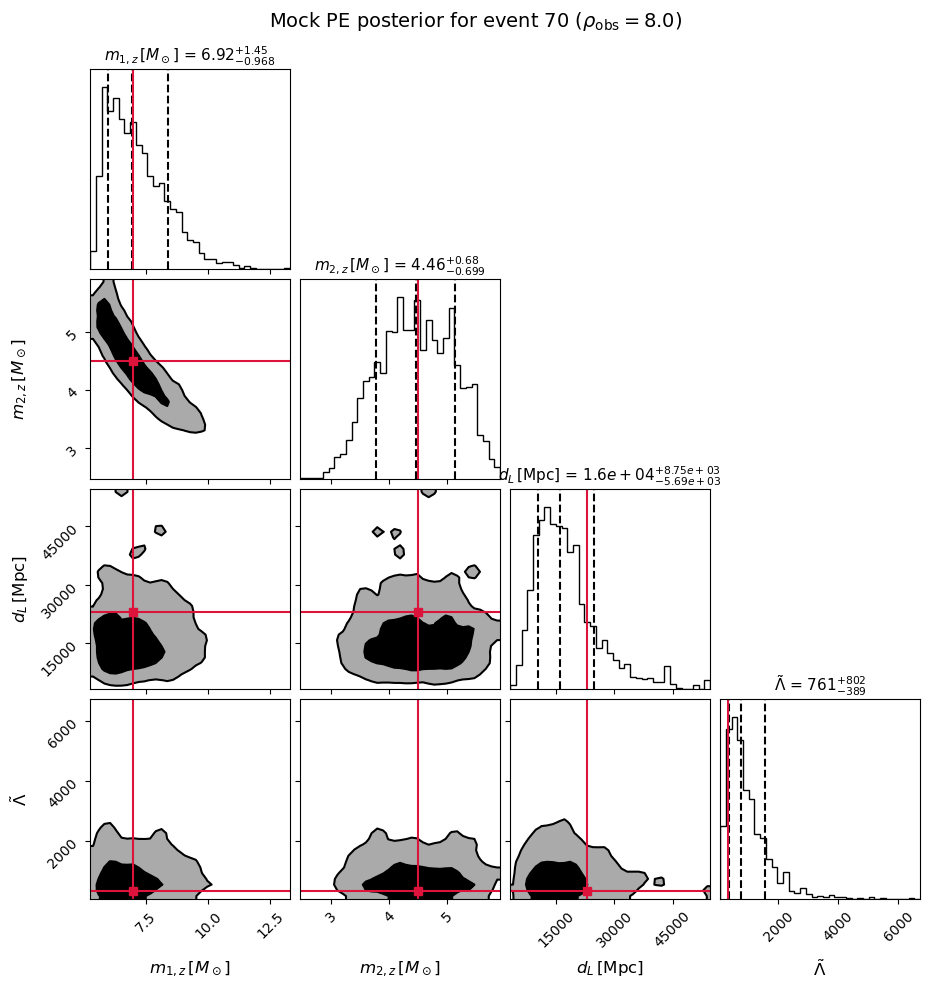

Saved figure to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/mock_pe_corner_physical_event070__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871.png


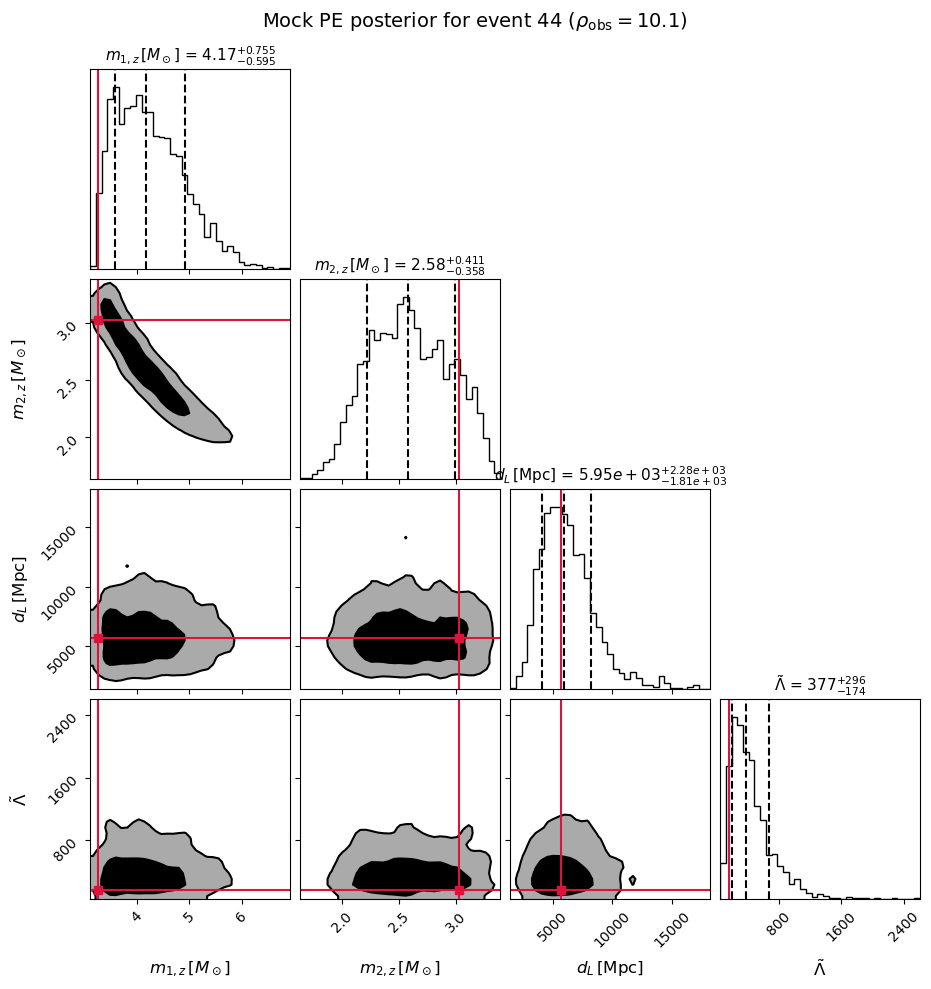

Saved figure to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/mock_pe_corner_physical_event044__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871.png


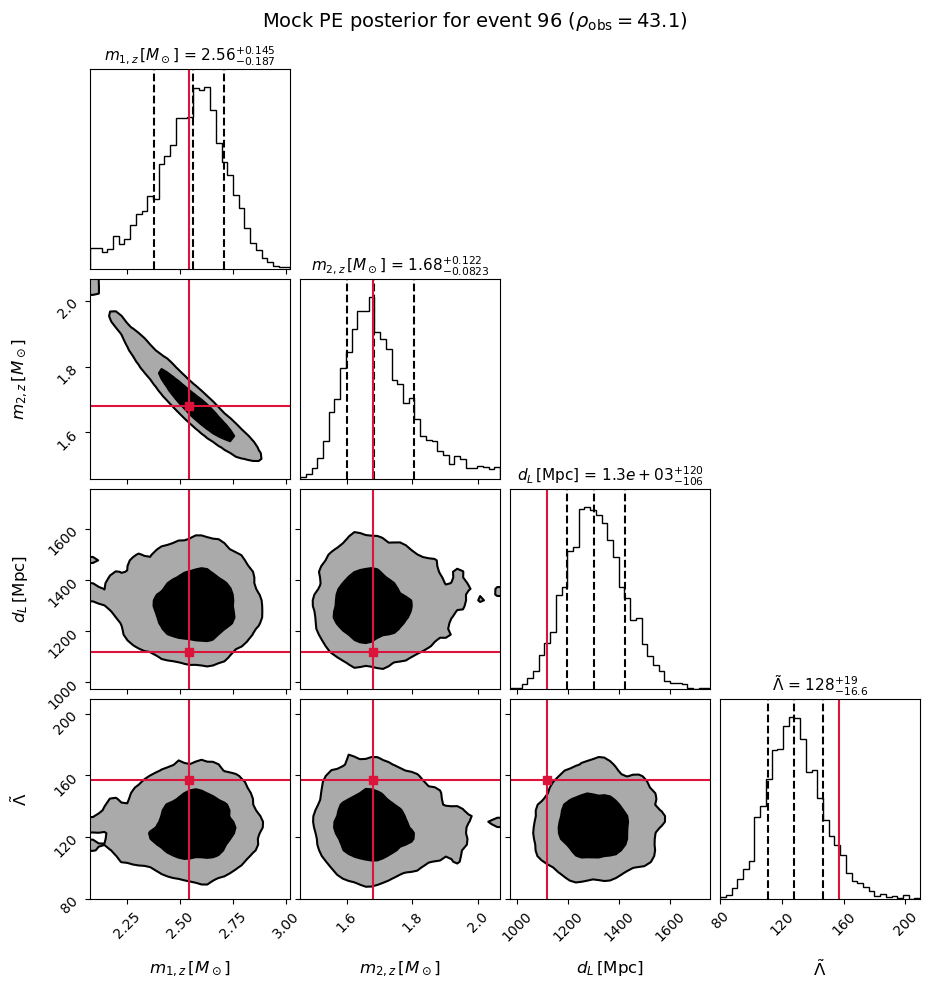

Saved figure to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/mock_pe_corner_physical_event096__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871.png


In [10]:
# Diagnostic: corner plots for a few mock PE posteriors
# in physical detector-frame variables:
# (m1_det, m2_det, d_L, Lambda_tilde).

import corner

# Choose representative events: low-SNR, median-SNR, and high-SNR detections.
events_to_plot = [
    int(np.argmin(rho_obs_selected)),
    int(np.argsort(rho_obs_selected)[len(rho_obs_selected) // 2]),
    int(np.argmax(rho_obs_selected)),
]

corner_labels = [
    r"$m_{1,z}\,[M_\odot]$",
    r"$m_{2,z}\,[M_\odot]$",
    r"$d_L\,[{\rm Mpc}]$",
    r"$\tilde{\Lambda}$",
]

# True injected values for the selected detected events.
# `idx = selected_indices` was defined earlier in the PE-generation cell.
true_m1_det_selected = m1_det[idx]
true_m2_det_selected = m2_det[idx]
true_d_l_selected = d_l[idx]
true_lambda_tilde_selected = lambda_tilde[idx]

for event_id in events_to_plot:
    samples_corner = np.column_stack(
        [
            pe_m1_det[event_id],
            pe_m2_det[event_id],
            pe_d_l[event_id],
            pe_lambda_tilde[event_id],
        ]
    )

    truth_corner = np.array(
        [
            true_m1_det_selected[event_id],
            true_m2_det_selected[event_id],
            true_d_l_selected[event_id],
            true_lambda_tilde_selected[event_id],
        ]
    )

    fig = corner.corner(
        samples_corner,
        labels=corner_labels,
        truths=truth_corner,
        truth_color="crimson",
        show_titles=True,
        title_fmt=".3g",
        title_kwargs={"fontsize": 11},
        label_kwargs={"fontsize": 12},
        quantiles=[0.16, 0.5, 0.84],
        levels=(0.5, 0.9),
        plot_datapoints=False,
        fill_contours=True,
        smooth=1.0,
        bins=35,
        max_n_ticks=4,
    )

    fig.suptitle(
        rf"Mock PE posterior for event {event_id} "
        rf"($\rho_{{\rm obs}}={rho_obs_selected[event_id]:.1f}$)",
        y=1.02,
        fontsize=14,
    )

    figure_path = (
        figures_dir
        / f"mock_pe_corner_physical_event{event_id:03d}__{eos_tag}__{pop_tag}__{detpe_tag}.png"
    )
    fig.savefig(figure_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved figure to {figure_path}")

## Save detected catalog and PE samples

We now save the mock detected catalog and the PE samples.

The detected-event file contains the true parameters of the selected events. These are useful for validation because, in this tutorial, we know the simulated truth.

The PE-sample file contains, for each event, posterior samples in the variables

$$
m_{1,z},
\qquad
m_{2,z},
\qquad
d_L,
\qquad
\tilde{\Lambda}.
$$

It also stores the PE-prior information needed for reweighting.

The distinction between the two files is important:

- the detected catalog contains the hidden true values used to generate the simulation;
- the PE samples mimic what a real analysis would provide to a population-inference pipeline.

In a real gravitational-wave analysis, we would not know the true event parameters. We would only have posterior samples and metadata describing the PE prior.

In [11]:
detected_output = processed_dir / f"detected_events__{eos_tag}__{pop_tag}__{detpe_tag}.npz"

np.savez(
    detected_output,
    eos_tag=eos_tag,
    eos_base_tag=eos_base_tag,
    fit_mass_tag=fit_mass_tag,
    pop_tag=pop_tag,
    detpe_tag=detpe_tag,
    population_filename=population_filename,
    seed=seed,
    target_n_detected=target_n_detected,
    rho_ref=rho_ref,
    mchirp_ref=mchirp_ref,
    d_l_ref=d_l_ref,
    rho_threshold=rho_threshold,
    orientation_model="finn_chernoff_beta_2_4",
    snr_model="rho_ref_mchirp_5over6_dL_inverse",
    rho_noise_model="normal_unit_sigma",
    selected_indices=selected_indices,
    m1=m1[idx],
    m2=m2[idx],
    z=z[idx],
    d_l=d_l[idx],
    m1_det=m1_det[idx],
    m2_det=m2_det[idx],
    mchirp_det=mchirp_det[idx],
    eta=eta[idx],
    lambda1=lambda1[idx],
    lambda2=lambda2[idx],
    lambda_tilde=lambda_tilde[idx],
    w=w[idx],
    rho_opt=rho_opt[idx],
    rho_true=rho_true[idx],
    rho_obs=rho_obs[idx],
)

pe_output = processed_dir / f"mock_pe_samples__{eos_tag}__{pop_tag}__{detpe_tag}.npz"

np.savez(
    pe_output,
    eos_tag=eos_tag,
    eos_base_tag=eos_base_tag,
    fit_mass_tag=fit_mass_tag,
    pop_tag=pop_tag,
    detpe_tag=detpe_tag,
    population_filename=population_filename,
    seed=seed,
    target_n_detected=target_n_detected,
    rho_ref=rho_ref,
    mchirp_ref=mchirp_ref,
    d_l_ref=d_l_ref,
    rho_threshold=rho_threshold,
    orientation_model="finn_chernoff_beta_2_4",
    snr_model="rho_ref_mchirp_5over6_dL_inverse",
    rho_noise_model="normal_unit_sigma",
    n_pe_samples=n_pe_samples,
    rho_error_ref=rho_error_ref,
    sigma_log_mchirp_ref=sigma_log_mchirp_ref,
    sigma_eta_ref=sigma_eta_ref,
    sigma_log_dl_ref=sigma_log_dl_ref,
    sigma_log_lambdatilde_ref=sigma_log_lambdatilde_ref,
    pe_likelihood_coordinates="log_mchirp_det,eta,log_d_l,log_lambda_tilde",
    pe_sample_coordinates="m1_det,m2_det,d_l,lambda_tilde",
    pe_prior="flat_m1det_m2det_flat_lambdatilde_dL2",
    true_log_mchirp=true_log_mchirp,
    true_eta=true_eta,
    true_log_dl=true_log_dl,
    true_log_lambdatilde=true_log_lambdatilde,
    obs_log_mchirp=obs_log_mchirp,
    obs_eta=obs_eta,
    obs_log_dl=obs_log_dl,
    obs_log_lambdatilde=obs_log_lambdatilde,
    sigma_log_mchirp=sigma_log_mchirp,
    sigma_eta=sigma_eta,
    sigma_log_dl=sigma_log_dl,
    sigma_log_lambdatilde=sigma_log_lambdatilde,
    m1_det=pe_m1_det,
    m2_det=pe_m2_det,
    d_l=pe_d_l,
    lambda_tilde=pe_lambda_tilde,
    log_mchirp=pe_log_mchirp,
    eta=pe_eta,
    log_d_l=pe_log_d_l,
    log_lambda_tilde=pe_log_lambda_tilde,
)

print(f"Saved detected catalog to {detected_output}")
print(f"Saved PE samples to {pe_output}")


Saved detected catalog to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/data/processed/detected_events__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871.npz
Saved PE samples to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/data/processed/mock_pe_samples__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871.npz


## Draw injections for the selection correction

Hierarchical inference must account for the fact that detected events are not a fair sample of the intrinsic population.

The selection correction involves the detectable fraction

$$
\xi(\lambda)
=
\int
p_{\rm det}(\theta)
p_{\rm pop}(\theta|\lambda)
\,d\theta.
$$

Here $\lambda$ denotes population hyperparameters and $\theta$ denotes event-level parameters.

This integral is usually estimated with injections. Injections are simulated sources drawn from a known reference distribution,

$$
p_{\rm draw}(\theta),
$$

passed through the detection process, and then used for Monte Carlo integration.

The estimator has the form

$$
\xi(\lambda)
\approx
\frac{1}{N_{\rm draw}}
\sum_{j\in{\rm detected}}
\frac{
p_{\rm pop}(\theta_j|\lambda)
}{
p_{\rm draw}(\theta_j)
}.
$$

This is why it is essential to know the injection draw density.

## Source-frame draw distribution

The injections are drawn internally in source-frame variables,

$$
(m_1,m_2,z).
$$

The source-frame draw density factorizes as

$$
p_{\rm draw}^{\rm src}(m_1,m_2,z)
=
p_{\rm draw}(m_1,m_2)
p_{\rm draw}(z).
$$

The two masses are drawn independently from the injection mass distribution and then ordered so that

$$
m_1 \geq m_2.
$$

Because either original draw could become the primary mass, the ordered mass density contains a factor of 2:

$$
p_{\rm draw}(m_1,m_2)
=
2\,p_{\rm draw}(m_1)p_{\rm draw}(m_2),
\qquad
m_1\geq m_2.
$$

Therefore,

$$
p_{\rm draw}^{\rm src}(m_1,m_2,z)
=
2\,p_{\rm draw}(m_1)p_{\rm draw}(m_2)p_{\rm draw}(z).
$$

In log form,

$$
\log p_{\rm draw}^{\rm src}
=
\log 2
+
\log p_{\rm draw}(m_1)
+
\log p_{\rm draw}(m_2)
+
\log p_{\rm draw}(z).
$$

## Detector-frame injection density

The hierarchical likelihood in notebook 03 will use detector-frame PE samples,

$$
(m_{1,z},m_{2,z},d_L).
$$

Therefore, for consistency, we store the injection draw density in the same detector-frame variables.

The transformation is

$$
m_{1,z}=(1+z)m_1,
\qquad
m_{2,z}=(1+z)m_2,
\qquad
d_L=d_L(z).
$$

We need the Jacobian of the transformation from source-frame variables to detector-frame variables.

The inverse transformation is

$$
m_1=\frac{m_{1,z}}{1+z},
\qquad
m_2=\frac{m_{2,z}}{1+z},
\qquad
z=z(d_L).
$$

The volume element transforms as

$$
dm_1\,dm_2\,dz
=
\frac{1}{(1+z)^2}
\frac{dz}{dd_L}
dm_{1,z}\,dm_{2,z}\,dd_L.
$$

Since

$$
\frac{dz}{dd_L}
=
\left(
\frac{dd_L}{dz}
\right)^{-1},
$$

we have

$$
dm_1\,dm_2\,dz
=
\frac{1}{(1+z)^2}
\left(
\frac{dd_L}{dz}
\right)^{-1}
dm_{1,z}\,dm_{2,z}\,dd_L.
$$

Therefore the detector-frame draw density is

$$
p_{\rm draw}^{\rm det}(m_{1,z},m_{2,z},d_L)
=
p_{\rm draw}^{\rm src}(m_1,m_2,z)
\frac{1}{(1+z)^2}
\left(
\frac{dd_L}{dz}
\right)^{-1}.
$$

Equivalently,

$$
\log p_{\rm draw}^{\rm det}
=
\log p_{\rm draw}^{\rm src}
-
2\log(1+z)
-
\log\left(
\frac{dd_L}{dz}
\right).
$$

This is the expression implemented below.

## What is included in the injection draw density?

The draw density includes the variables used to draw the source:

$$
(m_1,m_2,z)
\quad \text{or equivalently} \quad
(m_{1,z},m_{2,z},d_L).
$$

Note that the orientation factor $w$ is not included in the astrophysical population density. 

In [11]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def bounded_smooth_pdf(m, m_min, m_max, edge_width, edge_pdf_value):
    logit_edge = np.log((1.0 - edge_pdf_value) / edge_pdf_value)
    edge_scale = edge_width / logit_edge

    left = sigmoid((m - m_min - edge_width) / edge_scale)
    right = sigmoid((m_max - edge_width - m) / edge_scale)
    return left * right

def make_normalized_pdf(grid, pdf_unnormalized):
    norm = np.trapezoid(pdf_unnormalized, grid)
    return pdf_unnormalized / norm, norm

def merger_rate_density(z):
    numerator = (1.0 + z) ** alpha_z_inj
    denominator = 1.0 + ((1.0 + z) / (1.0 + z_p_inj)) ** (alpha_z_inj + beta_z_inj)
    return numerator / denominator

def redshift_pdf_unnormalized(z):
    dvc_dz = cosmology.differential_comoving_volume(z).value
    return merger_rate_density(z) * dvc_dz / (1.0 + z)

def draw_from_grid_pdf(grid, pdf, n):
    cdf = np.concatenate([[0.0], np.cumsum(0.5 * (pdf[1:] + pdf[:-1]) * np.diff(grid))])
    cdf /= cdf[-1]
    u = rng.uniform(size=n)
    return np.interp(u, cdf, grid)


The injection draw distribution does not need to match the true population exactly. It only needs to cover the region of parameter space where detectable events can occur.

In practice, a poor injection distribution leads to large Monte Carlo variance in the selection correction. A good injection distribution places enough samples in the regions where the population model and detection probability are large.

Here we use a broad injection distribution with mass support covering the EOS-valid range and redshifts up to `z_draw_max`.

In [12]:
m_draw_min = m_min_inj
m_draw_max = m_max_inj

m_draw_grid = np.linspace(m_draw_min, m_draw_max, 10000)
p_m_draw_unnorm = bounded_smooth_pdf(
    m_draw_grid,
    m_draw_min,
    m_draw_max,
    inj_edge_width,
    inj_edge_pdf_value,
)
p_m_draw_grid, _ = make_normalized_pdf(m_draw_grid, p_m_draw_unnorm)

z_draw_grid = np.linspace(0.0, z_draw_max, 100000)
p_z_draw_unnorm = redshift_pdf_unnormalized(z_draw_grid)
p_z_draw_grid, _ = make_normalized_pdf(z_draw_grid, p_z_draw_unnorm)

inj_a = draw_from_grid_pdf(m_draw_grid, p_m_draw_grid, 2 * n_inj_drawn)
inj_a = inj_a.reshape(n_inj_drawn, 2)

inj_m1 = np.maximum(inj_a[:, 0], inj_a[:, 1])
inj_m2 = np.minimum(inj_a[:, 0], inj_a[:, 1])
inj_z = draw_from_grid_pdf(z_draw_grid, p_z_draw_grid, n_inj_drawn)

inj_d_l = cosmology.luminosity_distance(inj_z).value
inj_m1_det = inj_m1 * (1.0 + inj_z)
inj_m2_det = inj_m2 * (1.0 + inj_z)
inj_mchirp_det = chirp_mass(inj_m1_det, inj_m2_det)
inj_eta = symmetric_mass_ratio(inj_m1_det, inj_m2_det)

inj_lambda1 = np.exp(np.polyval(pop["eos_chosen_coeffs"], inj_m1))
inj_lambda2 = np.exp(np.polyval(pop["eos_chosen_coeffs"], inj_m2))
inj_lambda_tilde = lambda_tilde_from_components(inj_m1, inj_m2, inj_lambda1, inj_lambda2)

inj_w = rng.beta(2.0, 4.0, size=n_inj_drawn)
inj_rho_opt, inj_rho_true = snr_model(inj_mchirp_det, inj_d_l, inj_w)
inj_rho_obs = rng.normal(inj_rho_true, 1.0)
inj_detected = inj_rho_obs > rho_threshold

log_p_m1 = np.log(np.interp(inj_m1, m_draw_grid, p_m_draw_grid))
log_p_m2 = np.log(np.interp(inj_m2, m_draw_grid, p_m_draw_grid))
log_p_z = np.log(np.interp(inj_z, z_draw_grid, p_z_draw_grid))

log_p_draw_source = np.log(2.0) + log_p_m1 + log_p_m2 + log_p_z
log_p_draw_det = (
    log_p_draw_source
    - 2.0 * np.log1p(inj_z)
    - np.log(ddL_dz(inj_z))
)

print(f"Drawn injections: {n_inj_drawn}")
print(f"Detected injections: {inj_detected.sum()}")


Drawn injections: 200000
Detected injections: 41709


### What to notice

The number of detected injections is much smaller than the number of drawn injections. This is expected: most simulated sources are too distant, too weak, or unfavorably oriented to pass the detection threshold.

The detected injections are the only injections that contribute to the Monte Carlo estimate of the selection factor,

$$
\xi(\lambda)
\approx
\frac{1}{N_{\rm draw}}
\sum_{j\in{\rm detected}}
\frac{
p_{\rm pop}(\theta_j|\lambda)
}{
p_{\rm draw}(\theta_j)
}.
$$

However, the normalization by the total number of drawn injections is also important. The estimator asks: out of all sources drawn from the reference distribution, what fraction would be detectable under a proposed population model?

## Save detected injections

We save only the detected injections, together with the information needed to evaluate the selection correction.

For each detected injection we store:

- detector-frame masses $m_{1,z},m_{2,z}$;
- source-frame masses $m_1,m_2$;
- redshift $z$ and luminosity distance $d_L$;
- tidal quantities $\Lambda_1,\Lambda_2,\tilde{\Lambda}$;
- observed SNR;
- the detector-frame draw density $p_{\rm draw}^{\rm det}$;
- the total number of injections drawn.

The total number of drawn injections is needed because the selection factor is normalized by $N_{\rm draw}$.

The detected injections will be used in notebook 03 to compute the selection correction for each proposed population and EOS model.

In [13]:
inj = inj_detected

injection_output = processed_dir / f"injections__{eos_tag}__{pop_tag}__{detpe_tag}__{inj_tag}.npz"

np.savez(
    injection_output,
    eos_tag=eos_tag,
    eos_base_tag=eos_base_tag,
    fit_mass_tag=fit_mass_tag,
    pop_tag=pop_tag,
    detpe_tag=detpe_tag,
    inj_tag=inj_tag,
    population_filename=population_filename,
    seed=seed,
    rho_ref=rho_ref,
    mchirp_ref=mchirp_ref,
    d_l_ref=d_l_ref,
    rho_threshold=rho_threshold,
    orientation_model="finn_chernoff_beta_2_4",
    snr_model="rho_ref_mchirp_5over6_dL_inverse",
    rho_noise_model="normal_unit_sigma",
    n_inj_drawn=n_inj_drawn,
    z_draw_max=z_draw_max,
    inj_edge_width=inj_edge_width,
    inj_edge_pdf_value=inj_edge_pdf_value,
    m_draw_min=m_draw_min,
    m_draw_max=m_draw_max,
    log_p_draw_coordinates="m1_det,m2_det,d_l",
    orientation_included_in_log_p_draw=False,
    m1=inj_m1[inj],
    m2=inj_m2[inj],
    z=inj_z[inj],
    d_l=inj_d_l[inj],
    m1_det=inj_m1_det[inj],
    m2_det=inj_m2_det[inj],
    mchirp_det=inj_mchirp_det[inj],
    eta=inj_eta[inj],
    lambda1=inj_lambda1[inj],
    lambda2=inj_lambda2[inj],
    lambda_tilde=inj_lambda_tilde[inj],
    w=inj_w[inj],
    rho_opt=inj_rho_opt[inj],
    rho_true=inj_rho_true[inj],
    rho_obs=inj_rho_obs[inj],
    log_p_draw=log_p_draw_det[inj],
)

print(f"Saved detected injections to {injection_output}")


Saved detected injections to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/data/processed/injections__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871.npz


## Diagnostic plot: SNR and detection

This plot compares the SNR distribution of the full intrinsic population to the SNR distribution of the detected catalog.

The detection threshold is applied to the noisy observed SNR,

$$
\rho_{\rm obs}>\rho_{\rm threshold}.
$$

Events close to threshold are affected by noise fluctuations. Some events with true SNR below threshold can scatter upward and be detected; some events above threshold can scatter downward and be missed.

The detected catalog is biased toward large observed SNR. This is the simplest visual signature of selection effects.

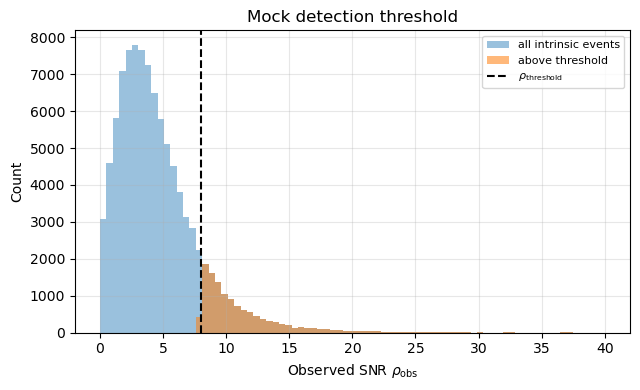

Saved figure to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/mock_detection_snr__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871.png


In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))

bins = np.linspace(0.0, max(40.0, np.percentile(rho_obs, 99.5)), 80)
ax.hist(rho_obs, bins=bins, alpha=0.45, label="all intrinsic events")
ax.hist(rho_obs[detected_mask], bins=bins, alpha=0.55, label="above threshold")
ax.axvline(rho_threshold, color="black", lw=1.5, ls="--", label=r"$\rho_{\rm threshold}$")

ax.set_xlabel(r"Observed SNR $\rho_{\rm obs}$")
ax.set_ylabel("Count")
ax.set_title("Mock detection threshold")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.tight_layout()
figure_path = figures_dir / f"mock_detection_snr__{eos_tag}__{pop_tag}__{detpe_tag}.png"
fig.savefig(figure_path, dpi=200)
plt.show()

print(f"Saved figure to {figure_path}")


## Diagnostic plot: PE residuals

The PE residuals check whether the mock observations are consistent with the Gaussian error model.

For each detected event and each PE coordinate, we plot residuals of the form

$$
r_x
=
\frac{
\hat{x}-x_{\rm true}
}{
\sigma_x
}.
$$

If the mock observations were generated correctly, these residuals should look approximately like draws from a standard normal distribution,

$$
r_x \sim \mathcal{N}(0,1).
$$

This diagnostic checks the noise model used to generate the mock PE centers. It verifies that the synthetic PE observations behave as intended.

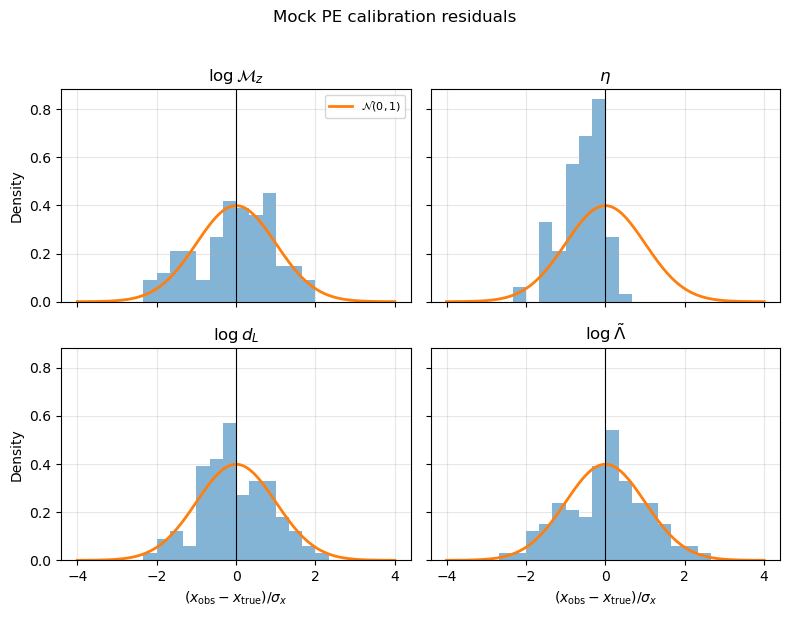

Saved figure to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/mock_pe_residuals__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871.png


In [15]:
residuals = [
    (obs_log_mchirp - true_log_mchirp) / sigma_log_mchirp,
    (obs_eta - true_eta) / sigma_eta,
    (obs_log_dl - true_log_dl) / sigma_log_dl,
    (obs_log_lambdatilde - true_log_lambdatilde) / sigma_log_lambdatilde,
]

labels = [
    r"$\log\mathcal{M}_z$",
    r"$\eta$",
    r"$\log d_L$",
    r"$\log\tilde{\Lambda}$",
]

x = np.linspace(-4.0, 4.0, 500)
normal_pdf = np.exp(-0.5 * x**2) / np.sqrt(2.0 * np.pi)

fig, axes = plt.subplots(2, 2, figsize=(8.0, 6.0), sharex=True, sharey=True)

for ax, residual, label in zip(axes.ravel(), residuals, labels):
    ax.hist(residual, bins=np.linspace(-4.0, 4.0, 25), density=True, alpha=0.55)
    ax.plot(x, normal_pdf, lw=2.0, label=r"$\mathcal{N}(0,1)$")
    ax.axvline(0.0, color="black", lw=0.8)
    ax.set_title(label)
    ax.grid(alpha=0.3)

axes[0, 0].set_ylabel("Density")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_xlabel(r"$(x_{\rm obs}-x_{\rm true})/\sigma_x$")
axes[1, 1].set_xlabel(r"$(x_{\rm obs}-x_{\rm true})/\sigma_x$")
axes[0, 0].legend(fontsize=8)

fig.suptitle("Mock PE calibration residuals", y=1.02)
fig.tight_layout()
figure_path = figures_dir / f"mock_pe_residuals__{eos_tag}__{pop_tag}__{detpe_tag}.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to {figure_path}")


## Diagnostic plot: injection coverage in observed space

This plot compares the detected events with the detected injections in the detector-frame variables used by the hierarchical likelihood.

The goal is to check that the detected injections cover the same region of parameter space as the observed catalog.

This matters because the selection correction is estimated by Monte Carlo integration over injections. If there are too few detected injections in the region where the observed events live, the selection correction will be noisy or biased.

The relevant variables are detector-frame quantities such as

$$
\log\mathcal{M}_{c,z},
\qquad
\eta,
\qquad
\log d_L.
$$

The injection set should broadly cover the detected-event region in these variables.

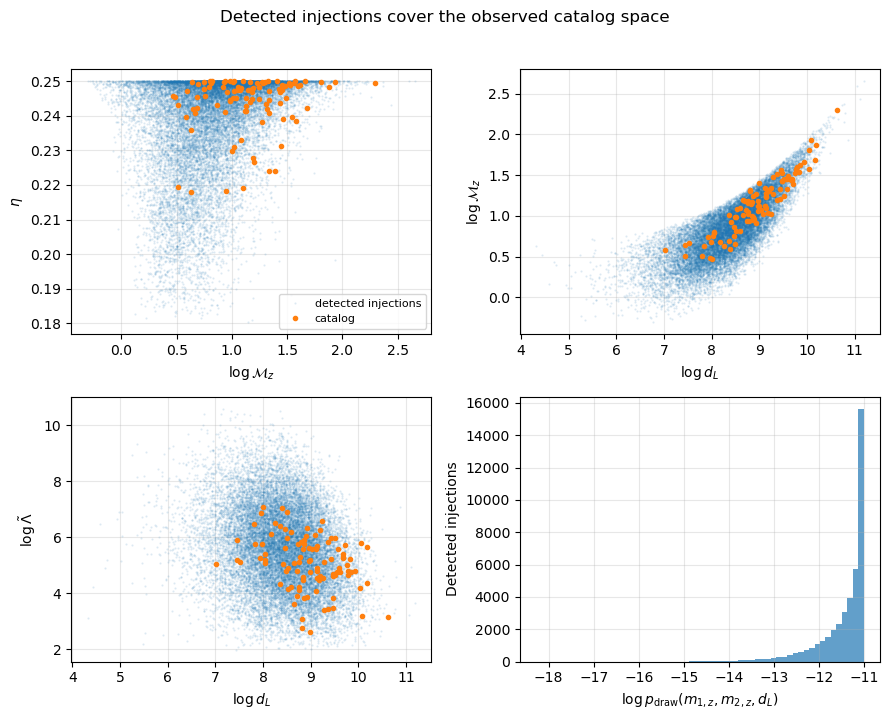

Saved figure to /Users/Michi/Library/CloudStorage/Dropbox/Local/Physics_projects/courses/ns-eos-population-tutorial/figures/injection_coverage_observed_space__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993__det_rho80_thr8_nev100_pe5000_seed1871__inj_n200000_z20_edge0p001_seed1871.png


In [16]:
det_log_mchirp = np.log(mchirp_det[idx])
det_eta = eta[idx]
det_log_dl = np.log(d_l[idx])
det_log_lambdatilde = np.log(lambda_tilde[idx])

inj_log_mchirp = np.log(inj_mchirp_det[inj])
inj_eta_det = inj_eta[inj]
inj_log_dl = np.log(inj_d_l[inj])
inj_log_lambdatilde = np.log(inj_lambda_tilde[inj])

max_points = min(20_000, len(inj_log_mchirp))
plot_inj_idx = rng.choice(len(inj_log_mchirp), size=max_points, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(9.0, 7.0))

ax = axes[0, 0]
ax.plot(inj_log_mchirp[plot_inj_idx], inj_eta_det[plot_inj_idx], ".", ms=1.0, alpha=0.15, label="detected injections")
ax.plot(det_log_mchirp, det_eta, "o", ms=3.0, label="catalog")
ax.set_xlabel(r"$\log\mathcal{M}_z$")
ax.set_ylabel(r"$\eta$")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(inj_log_dl[plot_inj_idx], inj_log_mchirp[plot_inj_idx], ".", ms=1.0, alpha=0.15)
ax.plot(det_log_dl, det_log_mchirp, "o", ms=3.0)
ax.set_xlabel(r"$\log d_L$")
ax.set_ylabel(r"$\log\mathcal{M}_z$")
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(inj_log_dl[plot_inj_idx], inj_log_lambdatilde[plot_inj_idx], ".", ms=1.0, alpha=0.15)
ax.plot(det_log_dl, det_log_lambdatilde, "o", ms=3.0)
ax.set_xlabel(r"$\log d_L$")
ax.set_ylabel(r"$\log\tilde{\Lambda}$")
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.hist(log_p_draw_det[inj], bins=60, alpha=0.7)
ax.set_xlabel(r"$\log p_{\rm draw}(m_{1,z},m_{2,z},d_L)$")
ax.set_ylabel("Detected injections")
ax.grid(alpha=0.3)

fig.suptitle("Detected injections cover the observed catalog space", y=1.02)
fig.tight_layout()
figure_path = figures_dir / f"injection_coverage_observed_space__{eos_tag}__{pop_tag}__{detpe_tag}__{inj_tag}.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to {figure_path}")


## Checkpoint

At the end of this notebook we have produced two ingredients needed for hierarchical inference.

First, for each detected event we have mock PE posterior samples:

$$
\left\{
m_{1,z}^{(k)},
m_{2,z}^{(k)},
d_L^{(k)},
\tilde{\Lambda}^{(k)}
\right\}_{k=1}^{N_i}.
$$

These samples represent

$$
p(\theta_i|d_i)
\propto
p(d_i|\theta_i)\pi_{\rm PE}(\theta_i).
$$

Second, we have a set of detected injections with known draw density

$$
p_{\rm draw}^{\rm det}(m_{1,z},m_{2,z},d_L).
$$

These injections will be used to estimate the selection factor

$$
\xi(\lambda)
=
\int
p_{\rm det}(\theta)
p_{\rm pop}(\theta|\lambda)
d\theta.
$$

The next notebook combines these two ingredients.

The event likelihood contribution will be approximated by reweighting PE samples,

$$
p(d_i|\lambda)
\approx
\frac{1}{N_i}
\sum_{k=1}^{N_i}
\frac{
p_{\rm pop}(\theta_i^{(k)}|\lambda)
}{
\pi_{\rm PE}(\theta_i^{(k)})
},
$$

and the selection correction will be approximated using injections.

Conceptually, notebook 02 answers the question:

> What would a detector and a simplified PE pipeline return for the intrinsic population generated in notebook 01?

Notebook 03 answers:

> Given those PE samples and injections, how do we infer the population and EOS parameters?